
# Lab_3: PDE with FDM

#### **Exercise 1**: Finite-differences method (FDM) with tolerance **Jacobi method**.


Solve the Laplace's equation in the dominio $0\leq x \leq L$ and $0\leq y \leq L$ with Dirichlet's boundary conditions:

* $u(x,0)=V(x)=f(x)\to V_0=100$ V
* $u(0,y)=0$
* $u(L,y)=0$
* $u(x,L)=0$

1. Solve the Laplace's equation using finite differences for an specific tolerance ($10^{-6}<\text{tol}<10^{-1}$). Do a plot of the field $u(x,y)$ for $\text{tol}=10^{-3}$. Explaint in words the strategy.
3. Compare with the Fourier serie. How many terms in the fourier serie are necessary to obtain a $\text{tol}=10^{-3}$?


#### **Exercise 2**: FDM for oppen boundaries (optional)

Solve analytically and numerically the **Laplace's equation** for $u(x,y)$ in the dominio $0\leq x \leq L$ and $0\leq y < \infty $, with Dirichlet's boundary conditions:

* $u(x,0)=V(x)=f(x) = u_0\sin(2\pi x/L)e^{-2\pi y/L}$
* $u(0,y)=0$
* $u(L,y)=0$
* $u(x,\infty)=0$


To solve numerically the Laplace's equation, set the lenght $L=N\Delta = 100$ and $\Delta=1$ and $u_0=100$.

<img src="https://github.com/anferivera/Fisica_Computacional_1/raw/main/Sesiones/PDE/figures/Laplace_df_4.png" width="300" height="400" />

In [10]:
# Exercise 1

import numpy as np
import matplotlib.pyplot as plt
"""
    Resolución de la ecuación de Laplace usando diferencias finitas (método de Jacobi).

    Estrategia:
    - Se discretiza el dominio en una malla de (N+1)x(N+1) puntos.
    - Las segundas derivadas se aproximan mediante diferencias centrales.
    - Esto lleva a una ecuación discreta donde cada punto interior es el promedio
      de sus cuatro vecinos.
    - Se usa un método iterativo (Jacobi) para actualizar la solución.
    - En cada iteración se calcula una nueva aproximación usando los valores anteriores.
    - El proceso se detiene cuando el error máximo entre iteraciones consecutivas
      es menor que la tolerancia (tol).
    - Las condiciones de frontera se imponen y permanecen fijas durante todo el proceso.
    """

def resol_laplace(N, tol=1e-3):
    u = np.zeros((N+1, N+1))

    # Condiciones de frontera
    u[:,0]  = 100   # abajo (y=0)
    u[:,-1] = 0     # arriba (y=L)
    u[0,:]  = 0     # izquierda (x=0)
    u[-1,:] = 0     # derecha (x=L)

    iteraciones = 0
    error = 1

    while error > tol:
        u_n = u.copy()

        for i in range(1, N):
            for j in range(1, N):
                u_n[i,j] = 0.25 * (
                    u[i+1,j] + u[i-1,j] +
                    u[i,j+1] + u[i,j-1]
                )

        error = np.max(np.abs(u_n - u))
        u = u_n
        iteraciones += 1

    return u, error, iteraciones

N = 40
u, error, i = resol_laplace(N)

print("Error final:", error)
print("Iteraciones:", i)

Error final: 0.0009997990034058546
Iteraciones: 1564


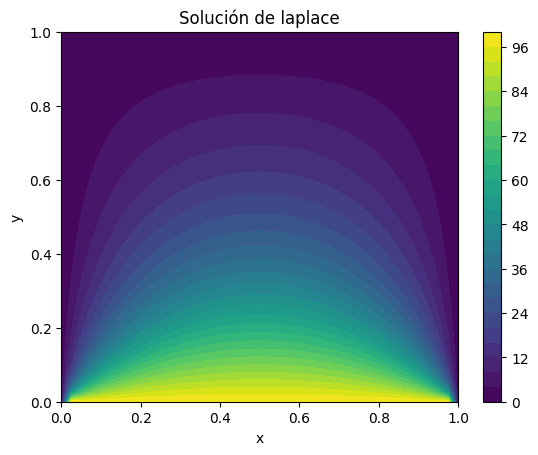

In [4]:
# Graficamos Posible solución

x = np.linspace(0, 1, N+1)
y = np.linspace(0, 1, N+1)

X, Y = np.meshgrid(x, y)

plt.contourf(X, Y, u.T, 25)
plt.colorbar()
plt.title("Solución de laplace")
plt.xlabel("x")
plt.ylabel("y")
plt.show()

In [8]:
def u_fourier(X, Y, M, L=1):
    U = np.zeros_like(X)

    for n in range(1, M+1):
        if n % 2 == 1:  # solo impares
            Bn = (400 / (n * np.pi)) * (1 / np.sinh(n * np.pi))

            U += Bn * np.sin(n * np.pi * X / L) * np.sinh(n * np.pi * (L - Y) / L)

    return U
U_fourier = u_fourier(X, Y, M=50)

error = np.max(np.abs(U_fourier[1:-1,1:-1] - u.T[1:-1,1:-1]))

print("Error Fourier vs FDM:", error)

Error Fourier vs FDM: 0.7115234023999051


Nota 3.0 Revisado. regular.. Entrega tarde. Quizás mal el git push!